# Positional encoding: telling the model where a token is

**The whole idea in one sentence:** attention treats a sentence as a bag of tokens,
so give every slot its own small vector and add it to whichever word lands there.

That's it. Everything else here is (a) where the numbers in those slot vectors come
from and (b) the ways this goes quietly wrong — because none of the failures raise.
A model with no positions trains. Its loss goes down. It just can't tell
*dog bites man* from *man bites dog*, and nothing will tell you.

By the end you'll have:

- built attention on three two-number words and watched it give the **same output
  for both word orders**
- fixed it with three rows of numbers written by hand
- trained a model that cannot see order, watched its loss drop and then stop at
  exactly `ln(3)`, and trained the same model *with* positions to zero
- built the sinusoidal table from scratch, watched one wave collide with itself and
  a stack of them not, and computed how far you'd have to go before the real table
  repeats (~60,000 tokens)
- built a detector for "the token two slots behind me" that works from **any**
  position with one fixed turn — the property RoPE is built on
- made the slot vector drown out the word, which is the trap the original paper's
  `sqrt(d_model)` multiplier exists for

In [1]:
import itertools
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.set_printoptions(precision=2, suppress=True, linewidth=100)
torch.set_printoptions(precision=2, sci_mode=False, linewidth=100)

try:
    import matplotlib
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False
    print("matplotlib not installed - plot cells will print a note instead "
          "(uv sync --extra demo)")

---
## 1. Attention is a bag

Three words, each a vector of two numbers. Small enough to check by hand.

In [2]:
words = {"dog": [1.0, 0.0], "bites": [0.0, 1.0], "man": [1.0, 1.0]}

def embed(sentence):
    return torch.tensor([words[w] for w in sentence.split()])

print(embed("dog bites man"))

tensor([[1., 0.],
        [0., 1.],
        [1., 1.]])


Here is attention with every weight stripped out. Each token scores every other
token by similarity, turns the scores into weights that sum to one, and becomes a
weighted mix of all the tokens. That's the whole mechanism — everything a real
attention layer adds (learned projections, heads, a causal mask) is decoration on
top of these three lines.

In [3]:
def attend(x):
    scores = x @ x.T               # how much each token cares about each other token
    weights = scores.softmax(-1)   # rows sum to 1
    return weights @ x             # each token becomes a weighted mix of all tokens

a = attend(embed("dog bites man"))
b = attend(embed("man bites dog"))

print("dog bites man ->\n", a)
print("\nman bites dog ->\n", b)
print("\nwhat 'bites' becomes, in each:", a[1], b[1])

dog bites man ->
 tensor([[0.84, 0.58],
        [0.58, 0.84],
        [0.79, 0.79]])

man bites dog ->
 tensor([[0.79, 0.79],
        [0.58, 0.84],
        [0.84, 0.58]])

what 'bites' becomes, in each: tensor([0.58, 0.84]) tensor([0.58, 0.84])


Same rows, different order. **Nothing after this layer can tell which sentence came
in**, because every row was computed from the same bag of three vectors. The token
*bites* in particular came out identical, since in both sentences it looked around
and saw exactly `{dog, man}`.

Order was never written down anywhere. There is no "this is token 2" anywhere in the
input, so there is nothing for the model to read.

---
## 2. The fix: a vector per slot

Make a second little table — one row per *position* instead of per word — and add
its row to whatever word lands in that position.

In [4]:
slots = torch.tensor([[0.0, 0.5],    # slot 0
                      [0.5, 0.0],    # slot 1
                      [0.5, 0.5]])   # slot 2

def embed_with_position(sentence):
    return embed(sentence) + slots

for s in ("dog bites man", "man bites dog"):
    x = embed_with_position(s)
    print(f"{s}:")
    for w, row in zip(s.split(), x):
        print(f"   {w:6} -> {row.tolist()}")

dog bites man:
   dog    -> [1.0, 0.5]
   bites  -> [0.5, 1.0]
   man    -> [1.5, 1.5]
man bites dog:
   man    -> [1.0, 1.5]
   bites  -> [0.5, 1.0]
   dog    -> [1.5, 0.5]


Look at *dog* in the two runs: `[1.0, 0.5]` and `[1.5, 0.5]`. Same word, different
numbers, because it sat in a different slot. Now attention sees different bags:

In [5]:
a = attend(embed_with_position("dog bites man"))
b = attend(embed_with_position("man bites dog"))
print("what 'bites' becomes now:", a[1], b[1], " <- different")

what 'bites' becomes now: tensor([1.19, 1.22]) tensor([1.00, 1.14])  <- different


**That's the entire trick.** Each slot owns a small vector; it gets added to the word
in that slot; *dog first* and *dog last* arrive as different inputs. Attention still
works on bags — it's just that the bag now has position mixed into the same numbers
as meaning.

The thing people expect, and it doesn't happen, is that the model reads position as
a separate column saying "this is token 3". It doesn't. Position is smeared into
the word vector and never separated out again. The model has to learn, from data,
that `[1.0, 0.5]` and `[1.5, 0.5]` are both *dog*. That works because the slot
vectors are small and consistent: the same nudge in the same direction every time
slot 0 is used.

---
## 3. Where do the slot numbers come from? Option A: learn them

The slot table is a lookup table, exactly like the word embedding. So the first
answer is: start it random and let backprop tune it. Row 0 gets a gradient every
time slot 0 is used — which is every sequence — so it settles fast.

Here is the smallest experiment that shows it mattering. Six sentences (every
ordering of our three words), one attention layer, and a task attention cannot do
from a bag: **which word came first?**

In [6]:
VOCAB = ["dog", "bites", "man"]
sentences = [" ".join(p) for p in itertools.permutations(VOCAB)]
ids = torch.tensor([[VOCAB.index(w) for w in s.split()] for s in sentences])   # [6, 3]
answer = ids[:, 0]                                                             # who is in slot 0

for s, y in zip(sentences, answer):
    print(f"{s:16} -> first word is {VOCAB[y]!r}")

dog bites man    -> first word is 'dog'
dog man bites    -> first word is 'dog'
bites dog man    -> first word is 'bites'
bites man dog    -> first word is 'bites'
man dog bites    -> first word is 'man'
man bites dog    -> first word is 'man'


In [7]:
class Tiny(nn.Module):
    def __init__(self, use_positions, d=8):
        super().__init__()
        self.tok = nn.Embedding(3, d)
        self.pos = nn.Embedding(3, d) if use_positions else None   # one row per slot
        self.q, self.k, self.v = nn.Linear(d, d), nn.Linear(d, d), nn.Linear(d, d)
        self.head = nn.Linear(d, 3)

    def forward(self, ids):
        x = self.tok(ids)                                    # word vectors
        if self.pos is not None:
            x = x + self.pos(torch.arange(ids.shape[1]))     # ...plus the slot vector
        w = (self.q(x) @ self.k(x).transpose(-1, -2)).softmax(-1)
        x = w @ self.v(x)                                    # attention
        return self.head(x.mean(1))                          # pool the bag, guess who was first

def train(model, steps=300):
    opt = torch.optim.Adam(model.parameters(), lr=0.05)
    for step in range(steps):
        loss = F.cross_entropy(model(ids), answer)
        opt.zero_grad(); loss.backward(); opt.step()
        if step % 100 == 0 or step == steps - 1:
            print(f"   step {step:>3}   loss {loss.item():.4f}")

print(f"a model that cannot see order can do no better than ln(3) = {math.log(3):.4f}\n")
torch.manual_seed(0)
print("without positions"); train(Tiny(use_positions=False))
torch.manual_seed(0)
print("\nwith positions");   train(Tiny(use_positions=True))

a model that cannot see order can do no better than ln(3) = 1.0986

without positions


   step   0   loss 1.1455
   step 100   loss 1.0986
   step 200   loss 1.0986
   step 299   loss 1.0986

with positions
   step   0   loss 1.1103


   step 100   loss 0.0000
   step 200   loss 0.0000
   step 299   loss 0.0000


### Read that carefully — it's the first trap

The model without positions **trains**. Its loss goes down. And then it stops at
`1.0986`, which is `ln(3)`: the best you can do when every ordering of the same
three words looks identical is to guess uniformly among them. Nothing raised,
nothing warned. If you didn't know the floor you'd think it was learning slowly.

Give it three rows of slot numbers and the same model goes to zero. That is the
entire difference positional encoding makes.

This — `nn.Embedding(max_seq_len, d_model)` added to the token embedding — is what
GPT-2 does. The rows are learned; the model figures out what "slot 17" should look
like. The two things it cannot do are cheap to name: it has no row for a position it
never saw in training, and it starts with no idea that slot 3 is *near* slot 4.

---
## 4. Option B: write the numbers down — the sinusoidal table

The original Transformer didn't learn the table. It filled it with a formula.

Think of each pair of channels as a **wheel**. As position increases the wheel
turns, and the pair holds where the hand is pointing: `(sin, cos)` of the angle.
Different pairs are wheels turning at different speeds. Trace two by hand — one
that turns a quarter turn per token, one an eighth:

In [8]:
def wheel(pos, turns_per_token):
    angle = 2 * math.pi * turns_per_token * pos
    return math.sin(angle), math.cos(angle)

print("pos   wheel A: 1/4 turn/token   wheel B: 1/8 turn/token")
for p in range(9):
    (sa, ca), (sb, cb) = wheel(p, 1 / 4), wheel(p, 1 / 8)
    mark = "   <- A is back where it started" if p in (4, 8) else ""
    print(f"{p:>3}   ({sa:>5.2f}, {ca:>5.2f})            ({sb:>5.2f}, {cb:>5.2f}){mark}")

pos   wheel A: 1/4 turn/token   wheel B: 1/8 turn/token
  0   ( 0.00,  1.00)            ( 0.00,  1.00)
  1   ( 1.00,  0.00)            ( 0.71,  0.71)
  2   ( 0.00, -1.00)            ( 1.00,  0.00)
  3   (-1.00, -0.00)            ( 0.71, -0.71)
  4   (-0.00,  1.00)            ( 0.00, -1.00)   <- A is back where it started
  5   ( 1.00,  0.00)            (-0.71, -0.71)
  6   ( 0.00, -1.00)            (-1.00, -0.00)
  7   (-1.00, -0.00)            (-0.71,  0.71)
  8   (-0.00,  1.00)            (-0.00,  1.00)   <- A is back where it started


### "Wouldn't positions eventually get the same value?"

Yes — **for one wheel.** Wheel A at position 4 reads `(0, 1)`, identical to position
0. It has lapped. If the table were a single wave, positions would collide every few
tokens and the model would be lost.

But the model never sees one wheel. It sees the whole row. Position 0 is
`[0, 1, 0, 1]` and position 4 is `[0, 1, 0, -1]` — wheel B, turning half as fast, is
only halfway round. The row only repeats when *every* wheel is back at the start
together, which for these two is position 8. Add a wheel that laps every 16 tokens
and the repeat moves to 16. Add one at 32 and it moves to 32.

It's a clock: the second hand alone can't tell the time because it laps every
minute, but seconds + minutes + hours pin down the moment. Fast wheels distinguish
neighbours; slow wheels distinguish regions; read together, each position is unique.

(And why `cos` alongside `sin`? A sine of `0.7` alone could be a wheel on its way
up or on its way down. The pair says exactly where on the wheel you are.)

### The general function

The paper's formula is the same thing with wheel speeds chosen on a slide: wheel
`i` turns `base^(-2i / d_model)` radians per token. Wheel 0 turns one radian per
token; each later wheel is slower by a constant factor; the last one is almost
stationary.

In [9]:
def sinusoidal_table(max_len, d_model, base=10000.0):
    pos = torch.arange(max_len, dtype=torch.float32)[:, None]                       # [L, 1]
    rate = base ** (-torch.arange(0, d_model, 2, dtype=torch.float32) / d_model)   # [d/2] rad/token
    angle = pos * rate                                                               # [L, d/2]
    table = torch.empty(max_len, d_model)
    table[:, 0::2] = angle.sin()     # even channels: where each wheel's hand is, vertically
    table[:, 1::2] = angle.cos()     # odd channels: ...and horizontally
    return table

d, base = 8, 100.0
rate = base ** (-torch.arange(0, d, 2) / d)
print("wheel   rad/token   laps every (tokens)")
for i, r in enumerate(rate):
    print(f"  {i}      {r:.4f}       {2 * math.pi / r:>7.1f}")

wheel   rad/token   laps every (tokens)
  0      1.0000           6.3
  1      0.3162          19.9
  2      0.1000          62.8
  3      0.0316         198.7


Four wheels, four speeds, each about three times slower than the last. Here's what
that looks like as position increases — the sine channel of each wheel:

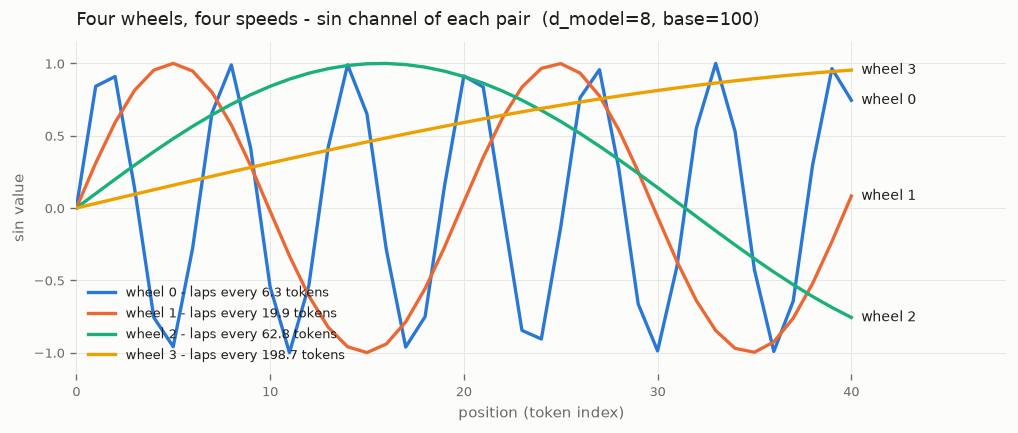

In [10]:
SURFACE, INK, INK2, GRID = "#fcfcfb", "#1f1e1d", "#6b6a63", "#e8e7e3"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]

def style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(color=GRID, lw=0.6)
    ax.tick_params(colors=INK2, labelsize=8)
    for s in ax.spines.values():
        s.set_visible(False)

if HAVE_MPL:
    L = 41
    t = sinusoidal_table(L, d, base).numpy()
    fig, ax = plt.subplots(figsize=(10, 3.6), dpi=120)
    fig.patch.set_facecolor(SURFACE); style(ax)
    for i in range(4):
        ax.plot(range(L), t[:, 2 * i], color=SERIES[i], lw=2,
                label=f"wheel {i} - laps every {2 * math.pi / rate[i]:.1f} tokens")
        ax.annotate(f"wheel {i}", (L - 1, t[-1, 2 * i]), xytext=(6, 0),
                    textcoords="offset points", color=INK, fontsize=8.5, va="center")
    ax.set_title("Four wheels, four speeds - sin channel of each pair  (d_model=8, base=100)",
                 color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("position (token index)", color=INK2, fontsize=9)
    ax.set_ylabel("sin value", color=INK2, fontsize=9)
    ax.legend(loc="lower left", fontsize=8, frameon=False, labelcolor=INK)
    ax.set_xlim(0, 48); ax.set_ylim(-1.15, 1.15)
    plt.show()
else:
    print("(plot skipped)")

And the whole table for a realistic `base`, positions along the bottom and channels
down the side. Every column is one position's fingerprint:

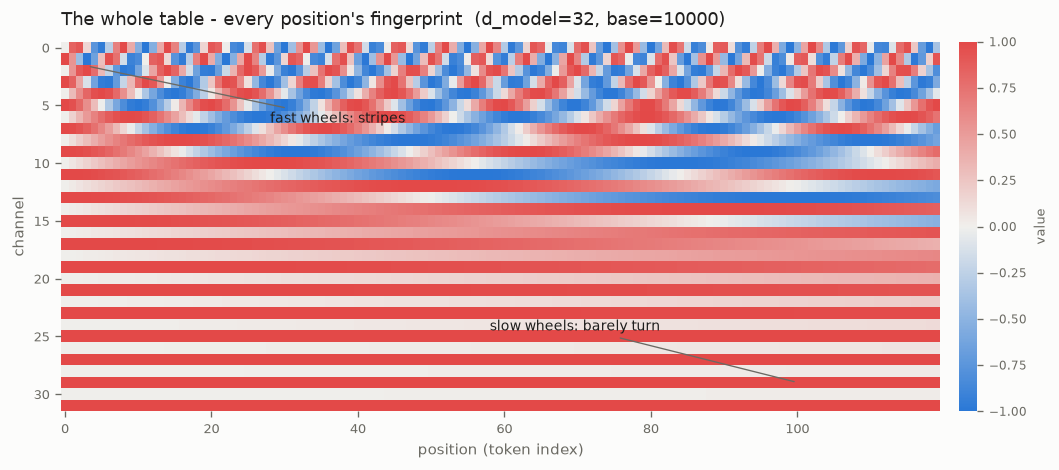

In [11]:
if HAVE_MPL:
    t2 = sinusoidal_table(120, 32).numpy().T
    cmap = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])
    fig, ax = plt.subplots(figsize=(10, 4), dpi=120)
    fig.patch.set_facecolor(SURFACE); style(ax); ax.grid(False)
    im = ax.imshow(t2, aspect="auto", cmap=cmap, vmin=-1, vmax=1, interpolation="nearest")
    ax.set_title("The whole table - every position's fingerprint  (d_model=32, base=10000)",
                 color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("position (token index)", color=INK2, fontsize=9)
    ax.set_ylabel("channel", color=INK2, fontsize=9)
    ax.annotate("fast wheels: stripes", (3, 1.6), xytext=(28, 6.5), textcoords="data",
                color=INK, fontsize=8.5, arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
    ax.annotate("slow wheels: barely turn", (100, 29), xytext=(58, 24.5), textcoords="data",
                color=INK, fontsize=8.5, arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
    cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cb.set_label("value", color=INK2, fontsize=8); cb.ax.tick_params(colors=INK2, labelsize=7)
    cb.outline.set_visible(False)
    plt.show()
else:
    print("(plot skipped)")

Stripes at the top: fast wheels lapping many times across 120 positions. Smooth
bands at the bottom: slow wheels that have barely moved. Every individual row is a
wave that repeats. No two columns are the same.

### So when *does* it repeat?

Measure it. For every position, take the worst channel's gap from position 0's row,
and report the position that gets closest. Do it twice: once with `base = 1`, which
makes every wheel turn at the *same* speed — so the table really is one wave — and
once with the paper's spread of speeds.

In [12]:
def nearest_twin(table):
    gap = (table - table[0]).abs().max(-1).values      # worst channel, per position
    gap[0] = float("inf")                              # position 0 is not its own twin
    p = int(gap.argmin())
    return p, float(gap[p])

for b, what in ((1.0, "every wheel at the same speed: one wave"),
                (10000.0, "the paper's spread of speeds")):
    p, g = nearest_twin(sinusoidal_table(4096, 8, b))
    print(f"base {b:>5.0f}  ({what})")
    print(f"   closest any of 4096 positions gets to position 0:  position {p}, "
          f"worst channel off by {g:.3f}\n")

base     1  (every wheel at the same speed: one wave)
   closest any of 4096 positions gets to position 0:  position 710, worst channel off by 0.000

base 10000  (the paper's spread of speeds)
   closest any of 4096 positions gets to position 0:  position 57, worst channel off by 0.551



One wave, and position 710 is an exact twin of position 0 — the collision you were
worried about, made real. Spread the speeds out and nothing within 4096 positions
comes close: on a scale where every entry lives between −1 and 1, the nearest
candidate has a channel off by more than half.

Exact repeats can't happen at all with the real spread, because the wheel speeds
aren't neat fractions of each other. Near-repeats need the *slowest* wheel to come
back round, and its lap is:

In [13]:
def slowest_lap(d_model, base=10000.0):
    return 2 * math.pi / base ** (-(d_model - 2) / d_model)

for dm in (8, 64, 768):
    print(f"d_model={dm:>4}:  slowest wheel laps every {slowest_lap(dm):>9,.0f} tokens")

d_model=   8:  slowest wheel laps every     6,283 tokens
d_model=  64:  slowest wheel laps every    47,117 tokens
d_model= 768:  slowest wheel laps every    61,343 tokens


For a real model that's about **60,000 tokens** before even the slowest wheel
returns — and every faster wheel would also need to line up at that moment. The
paper trained on sequences of a few hundred tokens. There is no collision to worry
about; the design puts it out of reach on purpose.

---
## 5. The property the wheels buy you: distance is one fixed turn

Random learned rows don't relate to each other. Wheels do — and this is the reason
the paper chose them over random numbers, and the reason RoPE exists.

Turning every wheel forward by `k` steps takes position `p`'s row to position
`p + k`'s row, **no matter what `p` is**. The turn doesn't know where it started:

In [14]:
def turn(row, k, base=10000.0):
    d_model = row.shape[-1]
    theta = k * base ** (-torch.arange(0, d_model, 2, dtype=torch.float32) / d_model)
    s, c = row[..., 0::2], row[..., 1::2]                 # each wheel's (sin, cos)
    out = torch.empty_like(row)
    out[..., 0::2] = s * theta.cos() + c * theta.sin()    # sin(a + theta)
    out[..., 1::2] = c * theta.cos() - s * theta.sin()    # cos(a + theta)
    return out

table = sinusoidal_table(256, 32)
for p in (0, 10, 100, 200):
    ok = torch.allclose(turn(table[p], 3), table[p + 3], atol=1e-5)
    print(f"turn(row {p:>3}, +3) == row {p + 3:>3}:  {ok}")

turn(row   0, +3) == row   3:  True
turn(row  10, +3) == row  13:  True
turn(row 100, +3) == row 103:  True
turn(row 200, +3) == row 203:  True


Now suppose a token wants to find the token **two slots behind it**. With random
rows it would need to memorise every pair: "3 goes with 1", "4 goes with 2", "5
goes with 3". With wheels, one rule does all of them: *take my own row, turn it back
two steps, and dot it with every other row.* The score is highest exactly where
the rows match.

In [15]:
def two_back_scores(m, table, base=10000.0):
    probe = turn(table[m], -2, base)      # "what would the row two behind me look like?"
    return table @ probe                  # compare against every position

for m in (3, 4, 50):
    scores = two_back_scores(m, table)
    lo = max(0, m - 4)
    print(f"from position {m:>2}: loudest match is position {int(scores.argmax()):>2}"
          f"   scores at positions {lo}..{m}: {scores[lo: m + 1].numpy()}")

from position  3: loudest match is position  1   scores at positions 0..3: [15.31 16.   15.31 13.73]
from position  4: loudest match is position  2   scores at positions 0..4: [13.73 15.31 16.   15.31 13.73]
from position 50: loudest match is position 48   scores at positions 46..50: [13.73 15.31 16.   15.31 13.73]


Same rule, same turn, fires two back from anywhere. Attention's scoring step is a
dot product between a *transformed* query and a key, and "turn every wheel by a
fixed angle" is exactly the kind of transform its weight matrix can hold. **So a
single learned weight can detect a distance, instead of memorising every pair of
positions.** Seen for every pair of positions at once:

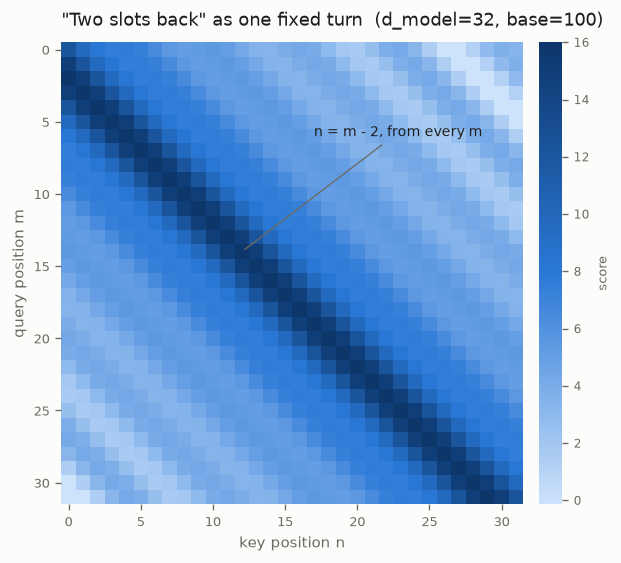

In [16]:
if HAVE_MPL:
    small = sinusoidal_table(32, 32, base=100.0)     # faster wheels, so the band stands out
    score = torch.stack([two_back_scores(m, small, base=100.0) for m in range(32)])   # [query m, key n]
    seq = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#2a78d6", "#0d366b"])
    fig, ax = plt.subplots(figsize=(5.6, 5), dpi=120)
    fig.patch.set_facecolor(SURFACE); style(ax); ax.grid(False)
    im = ax.imshow(score.numpy(), cmap=seq, interpolation="nearest")
    ax.set_title('"Two slots back" as one fixed turn  (d_model=32, base=100)',
                 color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("key position n", color=INK2, fontsize=9)
    ax.set_ylabel("query position m", color=INK2, fontsize=9)
    ax.annotate("n = m - 2, from every m", (12, 14), xytext=(17, 6), textcoords="data",
                color=INK, fontsize=8.5, arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
    cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
    cb.set_label("score", color=INK2, fontsize=8); cb.ax.tick_params(colors=INK2, labelsize=7)
    cb.outline.set_visible(False)
    plt.show()
else:
    print("(plot skipped)")

A clean diagonal, two below the main one. That line *is* "relative position" —
one weight, every position.

### What this does and doesn't guarantee

The wheels make the distance detector **available and cheap**. They don't force
the model to use it. The slot row is added to the word vector, so attention's dot
product also contains word × slot terms, and nothing stops the model from using the
absolute row directly when that's useful (is this token near the start of the
document?). Sinusoidal encoding *tends* toward relative position; it doesn't
*guarantee* it.

RoPE is what you get when you want the guarantee. Instead of adding the wheel row
at the input, it applies the turn to the query and key vectors themselves, inside
every attention layer, arranged so the absolute angles cancel in the dot product.
The score between two tokens then depends *only* on how far apart they are — by
construction, not by learning. That's the next notebook.

---
## 6. The second trap: the slot drowns out the word

Every entry of the sinusoidal table is a `sin` or `cos`, so a row's length is
`sqrt(d_model / 2)` no matter what. A token embedding initialised the usual way
(`N(0, 0.02)`) is *tiny* next to that.

In [17]:
d_model = 64
tok = nn.Embedding(3, d_model)
nn.init.normal_(tok.weight, std=0.02)          # the standard init
table = sinusoidal_table(3, d_model)

print(f"length of a word vector:  {tok.weight[0].norm():.2f}")
print(f"length of a slot row:     {table[0].norm():.2f}")

def sim(a, b):
    return F.cosine_similarity(a, b, dim=0).item()

dog0, man0, dog2 = tok.weight[0] + table[0], tok.weight[2] + table[0], tok.weight[0] + table[2]
print(f"\ndog@0 vs man@0  (different word, same slot):  {sim(dog0, man0):.4f}")
print(f"dog@0 vs dog@2  (same word, different slot):  {sim(dog0, dog2):.4f}")

length of a word vector:  0.17
length of a slot row:     5.66

dog@0 vs man@0  (different word, same slot):  0.9990
dog@0 vs dog@2  (same word, different slot):  0.8851


*Dog in slot 0* and *man in slot 0* are nearly the same vector. The slot is
shouting and the word is whispering. The model can still learn — gradients will
grow the word embeddings until they're heard — but it starts every run having to
dig the words out from under the positions.

The paper's fix is one line: multiply the token embeddings by `sqrt(d_model)` before
adding positions. That's *why* that multiplier is in the Transformer paper, and it's
easy to miss because it looks like a detail.

In [18]:
scaled = tok.weight * math.sqrt(d_model)
print(f"length of a scaled word vector:  {scaled[0].norm():.2f}   (slot row is still {table[0].norm():.2f})")
dog0, man0, dog2 = scaled[0] + table[0], scaled[2] + table[0], scaled[0] + table[2]
print(f"\ndog@0 vs man@0  (different word, same slot):  {sim(dog0, man0):.4f}")
print(f"dog@0 vs dog@2  (same word, different slot):  {sim(dog0, dog2):.4f}")

length of a scaled word vector:  1.39   (slot row is still 5.66)

dog@0 vs man@0  (different word, same slot):  0.9432
dog@0 vs dog@2  (same word, different slot):  0.8947


Still not equal partners at this init, but the word is now audible. (GPT-2 sidesteps
the whole thing: its *learned* slot table is initialised at the same `0.02` scale
as the words, so they start balanced.) The lesson is the general one: **the two
things you add together should be comparable in size.** Whichever one is bigger is
what the next layer mostly sees.

---
## 7. The packaged version

Everything above is in `litterbox.positional`, behind one interface with two hooks:
`embed` (add something to the residual stream, once, at the input — what this
notebook did) and `rotate` (turn queries and keys inside attention — what RoPE
does). Every strategy implements the hook it uses and leaves the other as identity,
so the backbone and the attention layer call both without knowing which strategy
they hold.

In [19]:
from litterbox.positional import Sinusoidal, available_positional, get_positional

print("registered strategies:", available_positional())

pos = Sinusoidal(d_model=32, max_seq_len=64)
x = torch.zeros(1, 5, 32)
print("same table as ours:", torch.allclose(pos.embed(x)[0], sinusoidal_table(5, 32)))

learned = Sinusoidal(d_model=32, max_seq_len=64, learnable=True)
print("learnable=True makes it a Parameter:", isinstance(learned.table, nn.Parameter),
      "- starts as the sinusoid, then training moves it")

try:
    pos.embed(torch.zeros(1, 65, 32))
except ValueError as e:
    print(f"\npast the table raises rather than guessing:\n   {e}")

registered strategies: ['nope', 'rope', 'sinusoidal']
same table as ours: True
learnable=True makes it a Parameter: True - starts as the sinusoid, then training moves it

past the table raises rather than guessing:
   positions 0..65 exceed the table's max_seq_len=64


And in the backbone it's the one call after the token lookup. With an empty stack
(no blocks yet) the first loss should sit at `ln(vocab_size)` — the check that the
targets aren't leaking:

In [20]:
from litterbox.model.transformer import Transformer

V, D = 512, 32
model = Transformer(vocab_size=V, d_model=D, pos=Sinusoidal(D, max_seq_len=64))
ids_ = torch.randint(0, V, (2, 16))
logits = model(ids_)
loss = F.cross_entropy(logits[:, :-1].reshape(-1, V), ids_[:, 1:].reshape(-1))
print(f"first loss {loss:.3f}    ln({V}) = {math.log(V):.3f}")

first loss 6.248    ln(512) = 6.238


---
## What to remember

| what | why |
|---|---|
| attention is a bag | its output is the same rows in any order; position has to be *added in* |
| a slot table, added once | learned (GPT-2) or written down (sinusoidal); the mechanism is identical |
| a stack of wheels doesn't repeat | one wave laps; the row only repeats when the slowest wheel does — ~60k tokens |
| distance is a fixed turn | one learned weight can detect "k back" from anywhere; RoPE makes that the *only* thing attention sees |
| keep the two parts comparable in size | or the slot drowns the word — the paper's `sqrt(d_model)` multiplier |

Two of these fail silently — a model with no positions trains, and a swamped word
embedding trains. Neither raises. That's why the floor check (`ln(3)` above,
`ln(vocab_size)` in the backbone) is worth having.

---

## Exercises

1. **Read the learned rows.** Train `Tiny(use_positions=True)`, then print its three
   slot rows. Are they anything like the ones you'd write by hand? Train it five
   times with different seeds — what stays the same?
2. **One slot back.** Build the detector for "the token immediately before me" and
   plot its score matrix. Then "three ahead". Which direction is which sign of `k`?
3. **Find the collision.** For `d_model = 8`, find the smallest `base` at which two
   positions inside 1,024 become near-twins (`tol = 0.1`). Then do it for
   `d_model = 32`. Why does a wider model tolerate a smaller `base`?
4. **Extrapolate.** Build `Sinusoidal(32, max_seq_len=64)` and feed it 128 tokens.
   The formula could compute position 100 — it's just `sin` and `cos` — but the
   packaged version raises. Read the error, then argue for or against that choice.
5. **Balance the sum.** In section 6, sweep the embedding scale from `0.02` to `2.0`
   and plot both cosine similarities against it. Where do the curves cross? Compare
   that scale to `sqrt(d_model)`.
6. **Make it real.** Write a `Learned` strategy — a random-init `nn.Embedding`
   slot table, `N(0, 0.02)` — and register it with
   `@register_positional("learned")` so `get_positional("learned")` finds it.
   Add it to `strategies()` in `tests/test_positional.py` and run the suite. That's
   the GPT-2 encoding, and it's the exercise that turns this notebook into a file
   in `src/`.